In [21]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

In [22]:
import sys
print(sys.executable)
print(sys.version)

/Users/anikalindell/_pettee/NNpractice/.venv/bin/python
3.14.3 (v3.14.3:323c59a5e34, Feb  3 2026, 11:41:37) [Clang 16.0.0 (clang-1600.0.26.6)]


In [23]:
# load data

training_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

from sklearn.model_selection import train_test_split

X = training_dataset.data
y = training_dataset.targets

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)


print(f"Training set has {len(X_train)} events.")
print(f"Validation set has {len(X_val)} events.")
print(f"Test set has {len(test_dataset)} events.")


Training set has 48000 events.
Validation set has 12000 events.
Test set has 10000 events.


In [24]:
X_train_normalized = X_train / 255.0
X_val_normalized = X_val / 255.0

# create dataloaders for training and testing datasets, allows for batch processing instead of feeding images one by one
train_dataset = TensorDataset(X_train_normalized, y_train)
val_dataset = TensorDataset(X_val_normalized, y_val)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False)

In [25]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim = 784, hidden_dim1 = 128, hidden_dim2 = 64, output_dim = 10):
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Linear(hidden_dim2, output_dim)
        )
    def forward(self, x):
        return self.NeuralNetwork(x)

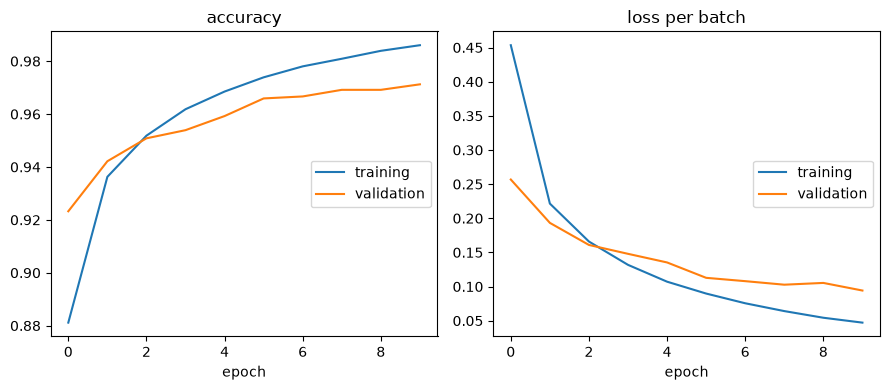

accuracy
	training         	 (min:    0.881, max:    0.986, cur:    0.986)
	validation       	 (min:    0.923, max:    0.971, cur:    0.971)
loss per batch
	training         	 (min:    0.047, max:    0.453, cur:    0.047)
	validation       	 (min:    0.094, max:    0.257, cur:    0.094)
Epoch 9, Loss: 0.002786359516903758
Dead ReLU neurons in first layer: 6 out of 128 (4.7%)


In [26]:
# training loop and plots

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

model = NeuralNetwork(input_dim = 784, hidden_dim1 = 128, hidden_dim2 = 64, output_dim = 10).to(device)
loss_fn = nn.CrossEntropyLoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # default learning rate for Adam optimizer is 0.001

print(model)

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

logs = {}

for epoch in range(10):  # loop over the dataset multiple times

    # training
    model.train()
    total_train_loss = 0
    train_acc, count = 0.0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss

        loss.backward()  # backward pass
    
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

        _, predicted = torch.max(out, dim=1)
        train_acc += (predicted == labels).sum().item()
        count += labels.size(0)


    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss per batch'] = train_loss_per_batch

    train_acc_per_count = train_acc/count
    logs['accuracy'] = train_acc_per_count


    # validation
    model.eval()
    all_predictions = []
    all_labels = []
    total_val_loss = 0
    val_acc, count = 0.0, 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        total_val_loss += loss.item()

        _, predicted = torch.max(out, dim=1)
        val_acc += (predicted == labels).sum().item()
        count += labels.size(0)

        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.cpu().numpy())


    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss per batch'] = val_loss_per_batch

    val_acc_per_count = val_acc/count
    logs['val_accuracy'] = val_acc_per_count

    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')

    # check dead neurons
    with torch.no_grad():
        # Slice your network to get activations from the first ReLU (indices 0, 1, 2)
        activated = model.NeuralNetwork[0:3](inputs)
        
        # Calculate dead neurons across this evaluation batch
        dead_neurons = (activated == 0).all(dim=0)
        num_dead = dead_neurons.sum().item()
        total_neurons = dead_neurons.numel()
        
        print(f"Dead ReLU neurons in first layer: {num_dead} out of {total_neurons} ({num_dead/total_neurons*100:.1f}%)")


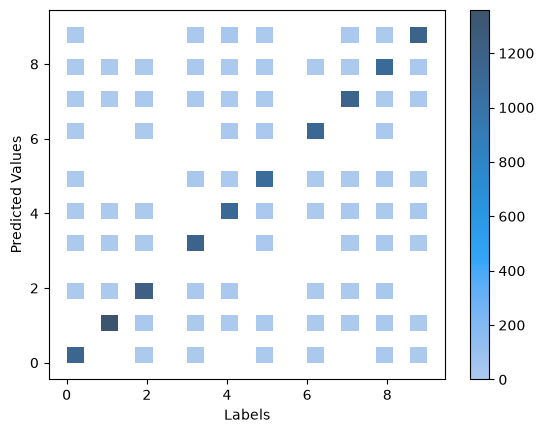

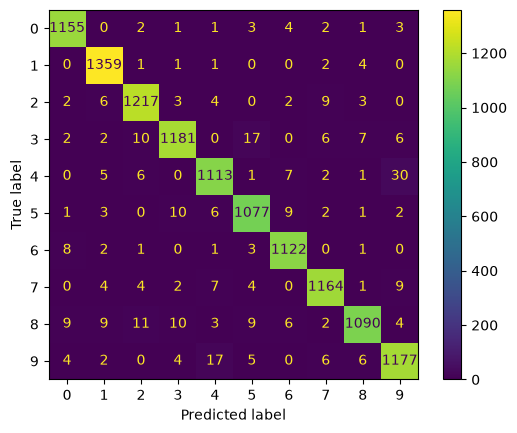

In [27]:
# plotting model performance
# true labels on x axis and predicted value on y axis

# plt.hist2d(all_labels, all_predictions, bins=9, cmap='grey')
# plt.colorbar(label='Counts per bin')
# plt.xlabel('Labels')
# plt.ylabel('Model Predictions')
# plt.show()

import seaborn as sns

data = {"Labels": all_labels, "Predicted Values": all_predictions}
df = pd.DataFrame(data)

sns.histplot(data=df, x="Labels", y="Predicted Values", stat='count', cbar=True)
plt.show()

# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

In [28]:
# compute accuracy on test set

model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device)
        labels = labels.to(device)
    
        out = model(inputs)
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(out, dim=1)
            
        # Track counts
        test_acc += (predicted == labels).sum().item()
        count += labels.size(0)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

Average test loss: 0.0788 | Test accuracy: 0.975


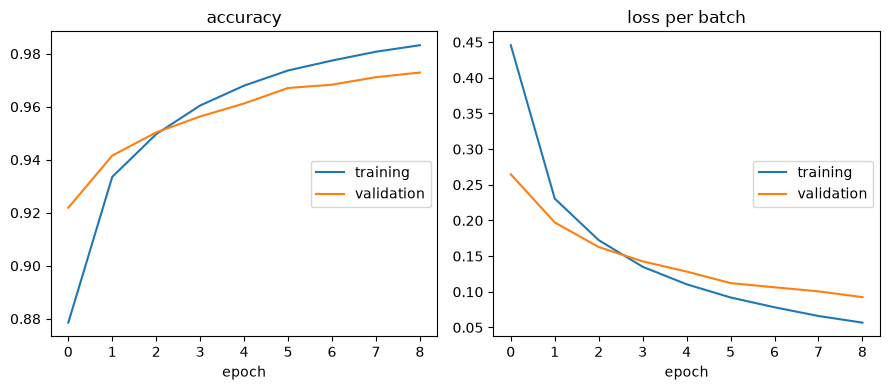

accuracy
	training         	 (min:    0.879, max:    0.983, cur:    0.983)
	validation       	 (min:    0.922, max:    0.973, cur:    0.973)
loss per batch
	training         	 (min:    0.057, max:    0.446, cur:    0.057)
	validation       	 (min:    0.093, max:    0.265, cur:    0.093)
Epoch 8, Loss: 0.001841824734583497
Early stopping


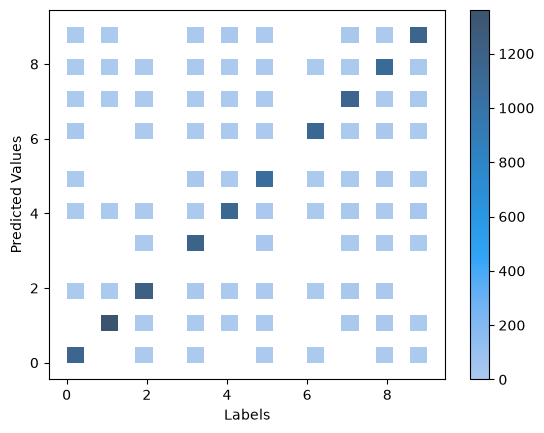

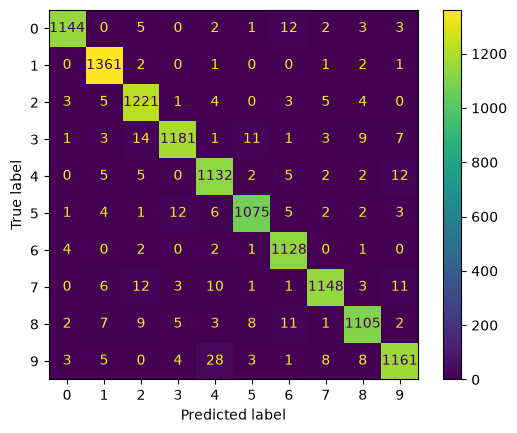

In [29]:
## train with early stopping

class EarlyStopping:
    def __init__(self, patience=2, delta=0):
        self.patience = patience
        self.delta = delta
        self.best_score = None
        self.early_stop = False
        self.counter = 0
        self.best_model_state = None

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.best_model_state = model.state_dict()
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.best_model_state = model.state_dict()
            self.counter = 0

    def load_best_model(self, model):
        model.load_state_dict(self.best_model_state)





# training loop and plots

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

model = NeuralNetwork(input_dim = 784, hidden_dim1 = 128, hidden_dim2 = 64, output_dim = 10).to(device)
loss_fn = nn.CrossEntropyLoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # default learning rate for Adam optimizer is 0.001
early_stopping = EarlyStopping(patience=2, delta=0.01)

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

logs = {}

for epoch in range(10):  # loop over the dataset multiple times

    # training
    model.train()
    total_train_loss = 0
    train_acc, count = 0.0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        loss.backward()  # backward pass
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

        _, predicted = torch.max(out, dim=1)
        train_acc += (predicted == labels).sum().item()
        count += labels.size(0)


    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss per batch'] = train_loss_per_batch

    train_acc_per_count = train_acc/count
    logs['accuracy'] = train_acc_per_count


    # validation
    model.eval()
    all_predictions = []
    all_labels = []
    total_val_loss = 0
    val_acc, count = 0.0, 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        total_val_loss += loss.item()

        _, predicted = torch.max(out, dim=1)
        val_acc += (predicted == labels).sum().item()
        count += labels.size(0)

        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.cpu().numpy())


    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss per batch'] = val_loss_per_batch

    val_acc_per_count = val_acc/count
    logs['val_accuracy'] = val_acc_per_count

    early_stopping(val_loss_per_batch, model)
    if early_stopping.early_stop:
        print("Early stopping")
        break

    early_stopping.load_best_model(model)


    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')


# plotting model performance
# true labels on x axis and predicted value on y axis

import seaborn as sns

data = {"Labels": all_labels, "Predicted Values": all_predictions}
df = pd.DataFrame(data)

sns.histplot(data=df, x="Labels", y="Predicted Values", stat='count', cbar=True)
plt.show()

# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

In [30]:
# compute accuracy on test set

model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_predictions = []
all_labels = []

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

logs = {}

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device)
        labels = labels.to(device)
    
        out = model(inputs)
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(out, dim=1)
            
        # Track counts
        test_acc += (predicted == labels).sum().item()
        count += labels.size(0)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

Average test loss: 0.0856 | Test accuracy: 0.973


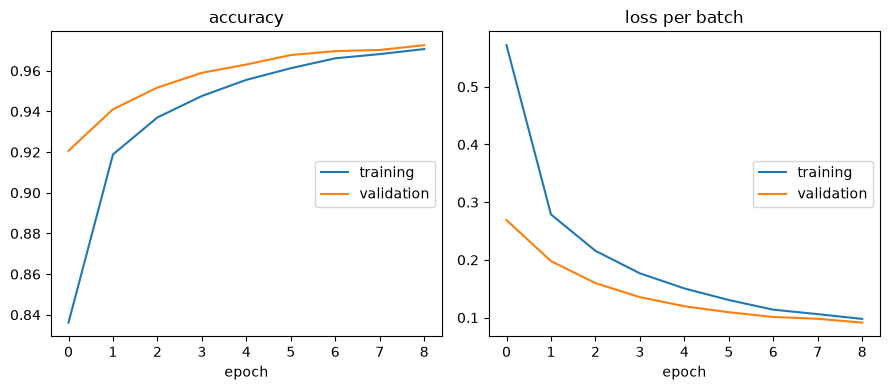

accuracy
	training         	 (min:    0.836, max:    0.971, cur:    0.971)
	validation       	 (min:    0.921, max:    0.973, cur:    0.973)
loss per batch
	training         	 (min:    0.098, max:    0.572, cur:    0.098)
	validation       	 (min:    0.091, max:    0.269, cur:    0.091)
Epoch 8, Loss: 0.0030859464313834906


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Early stopping


epoch,▁▂▃▄▅▅▆▇█
train_loss,█▄▃▂▂▁▁▁▁
val_loss,█▅▄▃▂▂▁▁▁
epoch,8
train_loss,0.09769
val_loss,0.09125


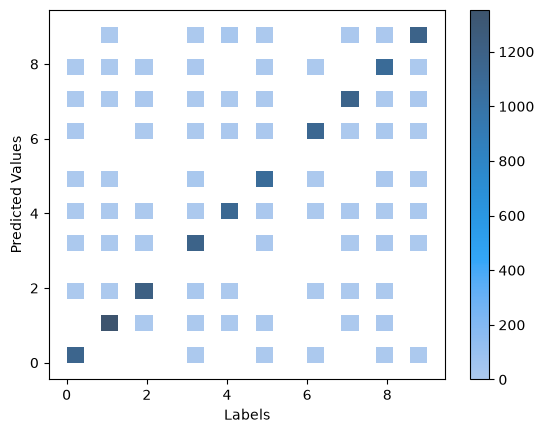

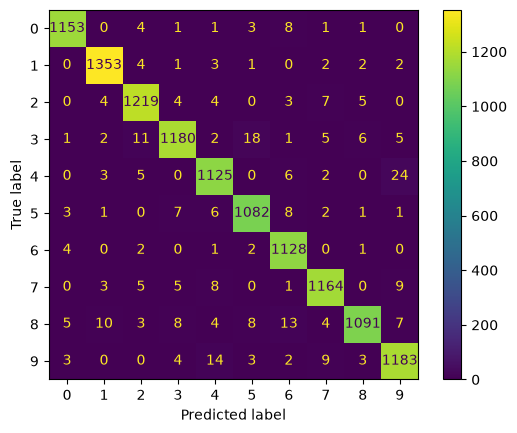

In [42]:
# try drop out

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim = 784, hidden_dim1 = 128, hidden_dim2 = 64, output_dim = 10):
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(hidden_dim2, output_dim)
        )
    def forward(self, x):
        return self.NeuralNetwork(x)


# training loop and plots

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

model = NeuralNetwork(input_dim = 784, hidden_dim1 = 128, hidden_dim2 = 64, output_dim = 10).to(device)
loss_fn = nn.CrossEntropyLoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # default learning rate for Adam optimizer is 0.001
early_stopping = EarlyStopping(patience=2, delta=0.01)

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

import wandb
wandb.init(project='watch-weights')

logs = {}

for epoch in range(10):  # loop over the dataset multiple times

    # training
    model.train()
    total_train_loss = 0
    train_acc, count = 0.0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        loss.backward()  # backward pass
        optimizer.step()  # update parameters

        total_train_loss += loss.item()

        _, predicted = torch.max(out, dim=1)
        train_acc += (predicted == labels).sum().item()
        count += labels.size(0)


    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss per batch'] = train_loss_per_batch

    train_acc_per_count = train_acc/count
    logs['accuracy'] = train_acc_per_count

##### visualizations of weights??

    wandb.watch(model, log="all", log_freq=100)


    # validation
    model.eval()
    all_predictions = []
    all_labels = []
    total_val_loss = 0
    val_acc, count = 0.0, 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        total_val_loss += loss.item()

        _, predicted = torch.max(out, dim=1)
        val_acc += (predicted == labels).sum().item()
        count += labels.size(0)

        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.cpu().numpy())


    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss per batch'] = val_loss_per_batch

    val_acc_per_count = val_acc/count
    logs['val_accuracy'] = val_acc_per_count

    early_stopping(val_loss_per_batch, model)
    if early_stopping.early_stop:
        print("Early stopping")
        break

    early_stopping.load_best_model(model)


    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')

    wandb.log({"train_loss": train_loss_per_batch, "val_loss": val_loss_per_batch, "epoch": epoch})


wandb.finish()


# plotting model performance
# true labels on x axis and predicted value on y axis

import seaborn as sns

data = {"Labels": all_labels, "Predicted Values": all_predictions}
df = pd.DataFrame(data)

sns.histplot(data=df, x="Labels", y="Predicted Values", stat='count', cbar=True)
plt.show()

# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

In [33]:
# compute accuracy on test set

model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device)
        labels = labels.to(device)
    
        out = model(inputs)
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(out, dim=1)
            
        # Track counts
        test_acc += (predicted == labels).sum().item()
        count += labels.size(0)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

Average test loss: 0.0863 | Test accuracy: 0.973


# Changing Architecture

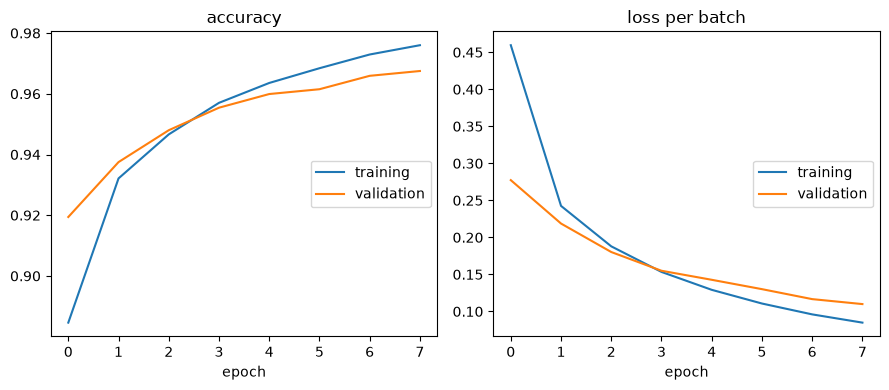

accuracy
	training         	 (min:    0.885, max:    0.976, cur:    0.976)
	validation       	 (min:    0.919, max:    0.968, cur:    0.968)
loss per batch
	training         	 (min:    0.085, max:    0.460, cur:    0.085)
	validation       	 (min:    0.110, max:    0.277, cur:    0.110)
Epoch 7, Loss: 0.01215827651321888
Early stopping


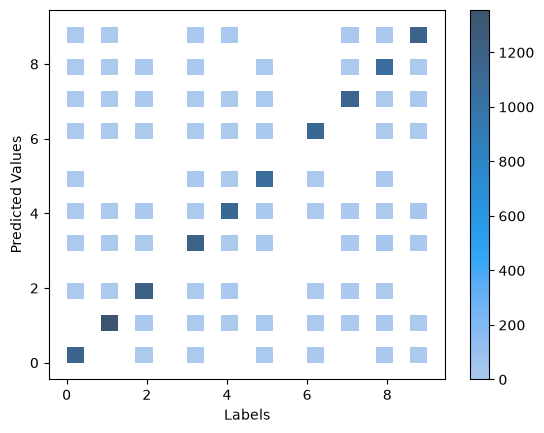

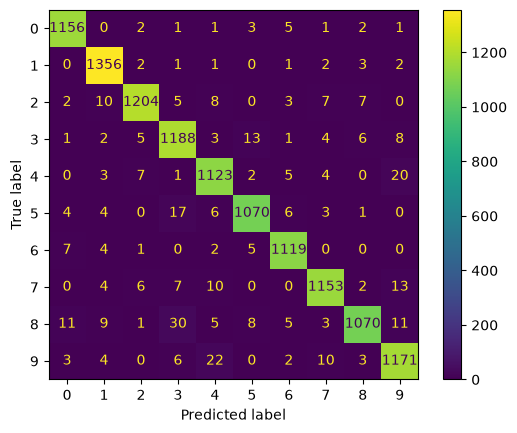

In [34]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim = 784, hidden_dim1 = 128, output_dim = 10):
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Linear(hidden_dim1, output_dim)
        )
    def forward(self, x):
        return self.NeuralNetwork(x)


# training loop and plots

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

model = NeuralNetwork(input_dim = 784, hidden_dim1 = 128, output_dim = 10).to(device)
loss_fn = nn.CrossEntropyLoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # default learning rate for Adam optimizer is 0.001
early_stopping = EarlyStopping(patience=2, delta=0.01)

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

logs = {}

for epoch in range(10):  # loop over the dataset multiple times

    # training
    model.train()
    total_train_loss = 0
    train_acc, count = 0.0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        loss.backward()  # backward pass
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

        _, predicted = torch.max(out, dim=1)
        train_acc += (predicted == labels).sum().item()
        count += labels.size(0)


    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss per batch'] = train_loss_per_batch

    train_acc_per_count = train_acc/count
    logs['accuracy'] = train_acc_per_count


    # validation
    model.eval()
    all_predictions = []
    all_labels = []
    total_val_loss = 0
    val_acc, count = 0.0, 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        total_val_loss += loss.item()

        _, predicted = torch.max(out, dim=1)
        val_acc += (predicted == labels).sum().item()
        count += labels.size(0)

        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.cpu().numpy())


    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss per batch'] = val_loss_per_batch

    val_acc_per_count = val_acc/count
    logs['val_accuracy'] = val_acc_per_count

    early_stopping(val_loss_per_batch, model)
    if early_stopping.early_stop:
        print("Early stopping")
        break

    early_stopping.load_best_model(model)


    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')

# plotting model performance
# true labels on x axis and predicted value on y axis

import seaborn as sns

data = {"Labels": all_labels, "Predicted Values": all_predictions}
df = pd.DataFrame(data)

sns.histplot(data=df, x="Labels", y="Predicted Values", stat='count', cbar=True)
plt.show()

# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

In [35]:
# compute accuracy on test set

model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device)
        labels = labels.to(device)
    
        out = model(inputs)
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(out, dim=1)
            
        # Track counts
        test_acc += (predicted == labels).sum().item()
        count += labels.size(0)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

Average test loss: 0.1013 | Test accuracy: 0.970


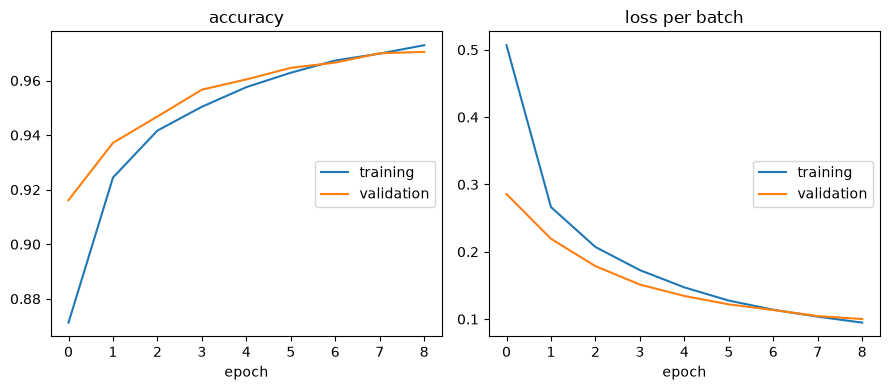

accuracy
	training         	 (min:    0.871, max:    0.973, cur:    0.973)
	validation       	 (min:    0.916, max:    0.971, cur:    0.971)
loss per batch
	training         	 (min:    0.095, max:    0.507, cur:    0.095)
	validation       	 (min:    0.100, max:    0.286, cur:    0.100)
Epoch 8, Loss: 0.03707880526781082
Early stopping


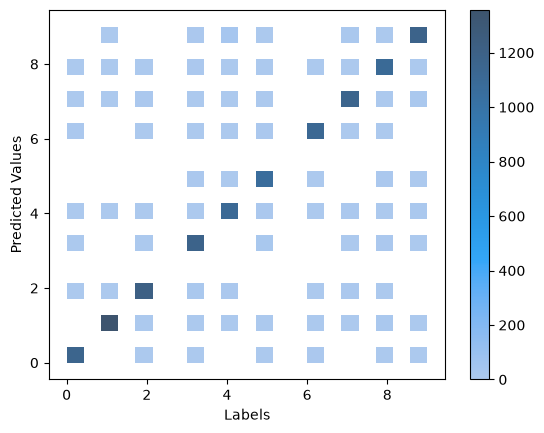

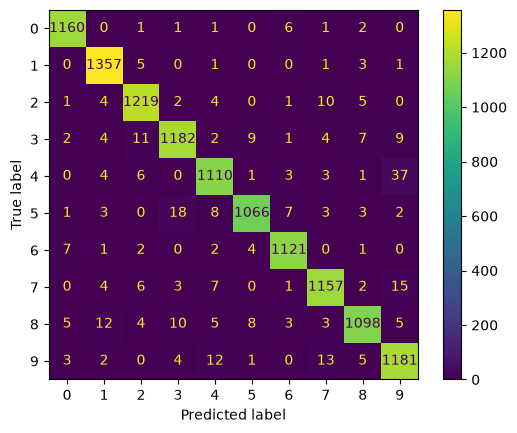

In [36]:
# try dropout with updated architecture

class NeuralNetwork(nn.Module):
    def __init__(self, input_dim = 784, hidden_dim1 = 128, output_dim = 10):
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(hidden_dim1, output_dim)
        )
    def forward(self, x):
        return self.NeuralNetwork(x)


# training loop and plots

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

model = NeuralNetwork(input_dim = 784, hidden_dim1 = 128, output_dim = 10).to(device)
loss_fn = nn.CrossEntropyLoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # default learning rate for Adam optimizer is 0.001
early_stopping = EarlyStopping(patience=2, delta=0.01)

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

logs = {}

for epoch in range(10):  # loop over the dataset multiple times

    # training
    model.train()
    total_train_loss = 0
    train_acc, count = 0.0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        loss.backward()  # backward pass
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

        _, predicted = torch.max(out, dim=1)
        train_acc += (predicted == labels).sum().item()
        count += labels.size(0)


    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss per batch'] = train_loss_per_batch

    train_acc_per_count = train_acc/count
    logs['accuracy'] = train_acc_per_count


    # validation
    model.eval()
    all_predictions = []
    all_labels = []
    total_val_loss = 0
    val_acc, count = 0.0, 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        total_val_loss += loss.item()

        _, predicted = torch.max(out, dim=1)
        val_acc += (predicted == labels).sum().item()
        count += labels.size(0)

        all_predictions.extend(predicted.numpy())
        all_labels.extend(labels.cpu().numpy())


    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss per batch'] = val_loss_per_batch

    val_acc_per_count = val_acc/count
    logs['val_accuracy'] = val_acc_per_count

    early_stopping(val_loss_per_batch, model)
    if early_stopping.early_stop:
        print("Early stopping")
        break

    early_stopping.load_best_model(model)


    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')


# plotting model performance
# true labels on x axis and predicted value on y axis

import seaborn as sns

data = {"Labels": all_labels, "Predicted Values": all_predictions}
df = pd.DataFrame(data)

sns.histplot(data=df, x="Labels", y="Predicted Values", stat='count', cbar=True)
plt.show()

# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

In [37]:
# compute accuracy on test set

model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_predictions = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device)
        labels = labels.to(device)
    
        out = model(inputs)
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        _, predicted = torch.max(out, dim=1)
            
        # Track counts
        test_acc += (predicted == labels).sum().item()
        count += labels.size(0)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

Average test loss: 0.0900 | Test accuracy: 0.972


In [38]:
# view parameters ??

print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: NeuralNetwork(
  (NeuralNetwork): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


Layer: NeuralNetwork.1.weight | Size: torch.Size([128, 784]) | Values : tensor([[ 0.0036, -0.0163, -0.0331,  ..., -0.0236, -0.0117,  0.0135],
        [-0.0025, -0.0299,  0.0010,  ..., -0.0180,  0.0067, -0.0350]],
       grad_fn=<SliceBackward0>) 

Layer: NeuralNetwork.1.bias | Size: torch.Size([128]) | Values : tensor([0.0396, 0.1680], grad_fn=<SliceBackward0>) 

Layer: NeuralNetwork.4.weight | Size: torch.Size([10, 128]) | Values : tensor([[-0.1471,  0.0374,  0.1042, -0.3349,  0.1591,  0.1263,  0.0919, -0.3689,
         -0.0612, -0.3164,  0.1318,  0.1332, -0.4166,  0.0053,  0.1557, -0.2121,
         -0.2184,  0.0224, -0.2427,  0.1412, -0.3825, -0.0931,  0.0629,  0.1032,
          0.1759, -0.4738,  0

In [39]:
weights = model.NeuralNetwork[1].weight.detach().cpu()
print(weights)

tensor([[ 0.0036, -0.0163, -0.0331,  ..., -0.0236, -0.0117,  0.0135],
        [-0.0025, -0.0299,  0.0010,  ..., -0.0180,  0.0067, -0.0350],
        [ 0.0151,  0.0038, -0.0159,  ...,  0.0323,  0.0312, -0.0093],
        ...,
        [ 0.0086, -0.0332, -0.0193,  ...,  0.0240, -0.0203,  0.0157],
        [ 0.0178, -0.0271,  0.0073,  ..., -0.0046, -0.0084, -0.0304],
        [-0.0231,  0.0054, -0.0113,  ..., -0.0248, -0.0110,  0.0270]])


In [40]:
print(f"Mean: {weights.mean():.4f}")
print(f"Std:  {weights.std():.4f}")
print(f"Min:  {weights.min():.4f}")
print(f"Max:  {weights.max():.4f}")

Mean: 0.0049
Std:  0.0784
Min:  -0.6423
Max:  0.4581


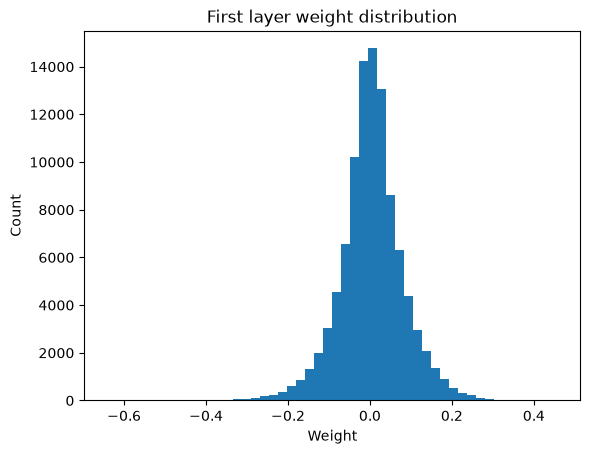

In [41]:
plt.hist(weights.flatten(), bins=50)
plt.xlabel("Weight")
plt.ylabel("Count")
plt.title("First layer weight distribution")
plt.show()